In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'no-latex', 'grid'])
from pathlib import Path

from Models import (
    DeletionImputer,
    ZeroImputer,
    EMImputer,
    KNNImputer,
    MahalanobisKNNImputer,
    BRITSImputer,
    CSDIImputer,
)
from Evaluations import Evaluator

In [3]:
seed = 69
rng = np.random.default_rng(seed)
FIG_DIR = Path("/Users/michelefanelli/Documents/Thesis/Latex/Figures")
FIG_DIR.mkdir(exist_ok=True)

## Data

`df` is the complete log-return panel (the ground truth). `Sparses`, `Gaps` and
`Stressed` hold copies of that panel with artificial missing values injected at
several intensities — each is a dict mapping the corruption level to a frame.

In [4]:
df = pd.read_csv("Data/log_returns.csv", index_col=0, parse_dates=True)


def load_corrupted(name):
    """Load every CSV in Data/<name>/ as a dict keyed by file stem."""
    base = Path("Data") / name
    return {
        f.stem: pd.read_csv(f, index_col=0, parse_dates=True)
        for f in sorted(base.glob("*.csv"))
    }


Sparses = load_corrupted("Sparses")
Gaps = load_corrupted("Gaps")
Stressed = load_corrupted("Stressed")

print("full panel:", df.shape)
print("Sparses :", list(Sparses))
print("Gaps    :", list(Gaps))
print("Stressed:", list(Stressed))

full panel: (4125, 50)
Sparses : ['0.001', '0.01', '0.05', '0.1', '0.3']
Gaps    : ['(1000, 10)', '(1000, 20)', '(20, 10)', '(200, 10)', '(2000, 30)']
Stressed: ['(0, 0.1, 0.99)', '(0.005, 0.5, 0.99)', '(0.04, 0.2, 0.95)', '(0.05, 0.5, 0.9)', '(0.2, 1, 0.9)']


## Imputers

Each imputer in `Models.py` shares the same interface — `fit`, `transform`,
`fit_transform` — taking a `(T, N)` panel with NaNs and returning a complete
panel with the observed cells left untouched (`DeletionImputer` is the
exception: it drops incomplete rows). The iterative models — `EMImputer`,
`BRITSImputer`, `CSDIImputer` — additionally record a `loss_history_` after
`fit` and accept `verbose=True`, so each can be trained on its own and watched
as it converges.

In [12]:
# The panel we'll work on (swap in any frame from Sparses / Gaps / Stressed).
panel = Sparses["0.05"]
print(f"panel: shape={panel.shape}, missing cells={int(panel.isna().sum().sum())}")

panel: shape=(4125, 50), missing cells=10409


## Train each model separately and watch it converge

We fit the iterative models one at a time with `verbose=True`. Each keeps a
per-iteration `loss_history_` (plotted together below). `epochs` is the main
speed/quality knob for the two neural models.

In [13]:
# EM's "loss" is the relative change in the estimated covariance per iteration --
# the parameter that actually drives the imputation -- which falls toward the
# tolerance over a handful of iterations. (Tracking the mean instead would stop
# after one step, since log-return means are ~0 and barely move.)
em = EMImputer(max_iter=50, verbose=True)
em.fit(panel)

EM    iter   1/50  cov update 1.08e-01
EM    iter   2/50  cov update 5.26e-03
EM    iter   3/50  cov update 9.74e-04
EM    iter   4/50  cov update 2.28e-04
EM    iter   5/50  cov update 5.95e-05


In [15]:
# BRITS -- raise epochs for better fits.
brits = BRITSImputer(epochs=2000, random_state=seed, verbose=True)
brits.fit(panel)

BRITS epoch    1/2000  loss 434.07200
BRITS epoch  200/2000  loss 285.99959
BRITS epoch  400/2000  loss 276.51617
BRITS epoch  600/2000  loss 274.70162
BRITS epoch  800/2000  loss 270.53984
BRITS epoch 1000/2000  loss 265.01371
BRITS epoch 1200/2000  loss 260.08974
BRITS epoch 1400/2000  loss 257.69812
BRITS epoch 1600/2000  loss 258.49361
BRITS epoch 1800/2000  loss 255.47095
BRITS epoch 2000/2000  loss 255.74952


In [ ]:
# CSDI is the heaviest model. Three things make it actually converge on this data:
#  - many small OVERLAPPING windows (window=32, stride=16) -> enough gradient steps
#    per epoch to train, and a much smoother loss curve;
#  - a randomized conditioning ratio while training (handled inside Models.py), so
#    the sampler stays calibrated for the ~95%-observed regime seen at inference;
#  - the imputation is the MEDIAN of n_samples reverse-diffusion draws -- a single
#    draw is very noisy on near-i.i.d. returns.
# Heavy on CPU (~5 min to train here, plus ~2 min to sample at n_samples=5); lower
# epochs / n_samples to trade quality for speed.
csdi = CSDIImputer(window=32, stride=8, epochs=5, n_samples=1,
                   random_state=seed, verbose=True)
csdi.fit(panel)

CSDI  epoch    1/5  loss 0.60101
CSDI  epoch    2/5  loss 0.42987
CSDI  epoch    3/5  loss 0.36165
CSDI  epoch    4/5  loss 0.38604
CSDI  epoch    5/5  loss 0.37573


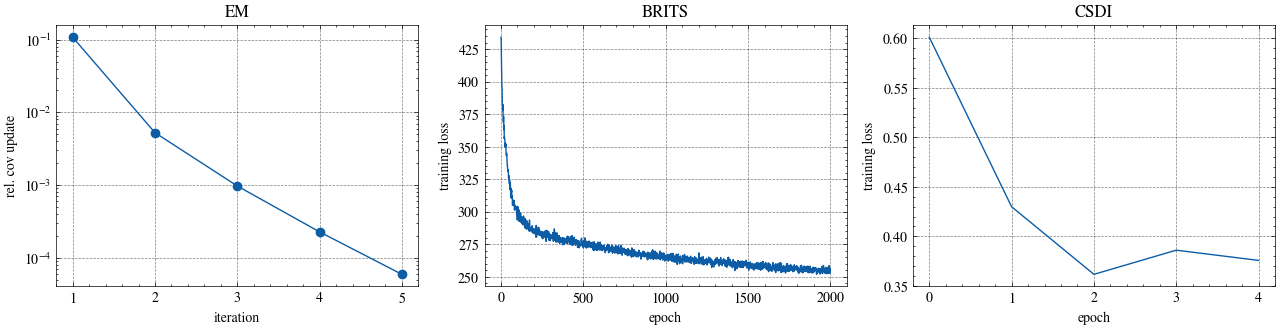

In [17]:
# Convergence curves. EM's metric is on a very different scale, so it gets its
# own (log-scale) panel.
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].semilogy(range(1, len(em.loss_history_) + 1), em.loss_history_, marker="o")
axes[0].set(title="EM", xlabel="iteration", ylabel="rel. cov update")
axes[1].plot(brits.loss_history_)
axes[1].set(title="BRITS", xlabel="epoch", ylabel="training loss")
axes[2].plot(csdi.loss_history_)
axes[2].set(title="CSDI", xlabel="epoch", ylabel="training loss")
fig.tight_layout()
plt.show()

## Reconstruct & compare

With the models trained, fill the panel with each and overlay the results on a
single asset as a sanity check. (Quantitative evaluation against `df` comes
later.)

In [18]:
# Assemble every reconstruction: the instant imputers via fit_transform, the
# already-trained ones via transform (no retraining).
reconstructed = {
    "Deletion": DeletionImputer().fit_transform(panel),
    "Zero":     ZeroImputer().fit_transform(panel),
    "KNN":      KNNImputer(n_neighbors=5, weights="distance").fit_transform(panel),
    "MahaKNN":  MahalanobisKNNImputer(n_neighbors=5, weights="distance").fit_transform(panel),
    "EM":       em.transform(panel),
    "BRITS":    brits.transform(panel),
    "CSDI":     csdi.transform(panel),
}
for name, Xi in reconstructed.items():
    Xi = np.asarray(Xi)
    note = "full panel" if Xi.shape == panel.shape else "rows dropped"
    print(f"{name:9s} -> {str(Xi.shape):12s} NaNs left={int(np.isnan(Xi).sum()):4d}  ({note})")

Deletion  -> (300, 50)    NaNs left=   0  (rows dropped)
Zero      -> (4125, 50)   NaNs left=   0  (full panel)
KNN       -> (4125, 50)   NaNs left=   0  (full panel)
MahaKNN   -> (4125, 50)   NaNs left=   0  (full panel)
EM        -> (4125, 50)   NaNs left=   0  (full panel)
BRITS     -> (4125, 50)   NaNs left=   0  (full panel)
CSDI      -> (4125, 50)   NaNs left=   0  (full panel)


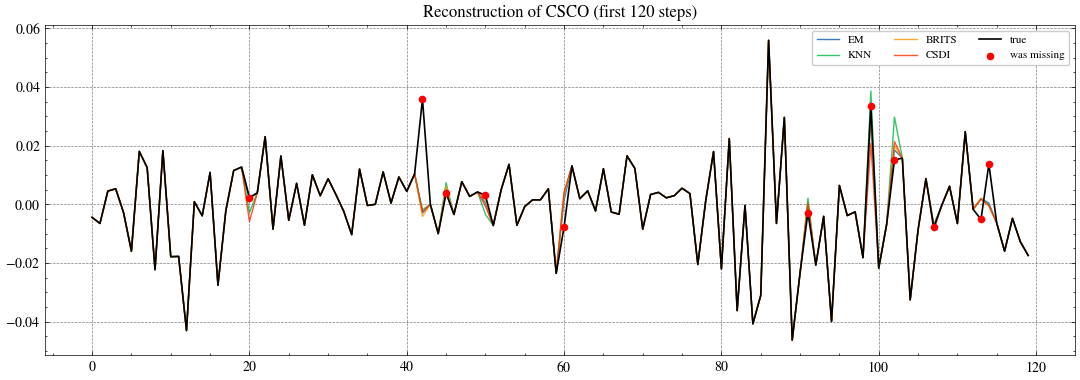

In [19]:

# Overlay one asset's reconstructions, with the originally-missing points in red.
asset, win = 3, 120
true = df.to_numpy()[:win, asset]
missing_idx = np.where(np.isnan(panel.to_numpy()[:win, asset]))[0]

plt.figure(figsize=(11, 4))
for name in ["EM", "KNN", "BRITS", "CSDI"]:
    plt.plot(np.asarray(reconstructed[name])[:win, asset], lw=1, alpha=0.8, label=name)
plt.plot(true, color="black", lw=1.2, label="true")
plt.scatter(missing_idx, true[missing_idx], color="red", s=20, zorder=5, label="was missing")
plt.legend(ncol=3, fontsize=8)
plt.title(f"Reconstruction of {df.columns[asset]} (first {win} steps)")
plt.tight_layout()
plt.show()

In [20]:
# True vs. reconstructed covariance matrix: relative Frobenius error (lower = better).
cov_true = np.cov(df.to_numpy(), rowvar=False)
cov_error = {
    name: np.linalg.norm(np.cov(np.asarray(Xi), rowvar=False) - cov_true) / np.linalg.norm(cov_true)
    for name, Xi in reconstructed.items()
}
pd.Series(cov_error, name="rel. cov error").sort_values()

BRITS       0.015031
EM          0.015133
KNN         0.028343
MahaKNN     0.052565
Zero        0.104353
Deletion    0.195070
CSDI        0.981881
Name: rel. cov error, dtype: float64

## Evaluation

Score every model on every missingness level with `Evaluations.py`. BRITS and
CSDI are **retrained from scratch on each panel**, so every missingness regime
gets its own fit (the fair, if expensive, comparison); the cheap imputers are fit
per panel too. MAE/RMSE are measured on the originally-missing cells; the other
metrics compare the full reconstructed panels against the ground truth `df`.

In [ ]:
# Pick the family to score; swap for Gaps / Stressed (or {**Sparses, **Gaps, **Stressed}).
# Every model is fit per panel -- BRITS and CSDI are retrained from scratch, so this is
# expensive (~10 min per level at these settings). Cut their `epochs` / CSDI's
# `n_samples` below for a quicker, rougher pass.
datasets = Sparses


def impute_all(corrupted):
    """Reconstruct one panel with every model; BRITS and CSDI are retrained on it."""
    return {
        "Deletion": DeletionImputer().fit_transform(corrupted),
        "Zero":     ZeroImputer().fit_transform(corrupted),
        "KNN":      KNNImputer(n_neighbors=5, weights="distance").fit_transform(corrupted),
        "MahaKNN":  MahalanobisKNNImputer(n_neighbors=5, weights="distance").fit_transform(corrupted),
        "EM":       EMImputer(max_iter=50).fit_transform(corrupted),
        "BRITS":    BRITSImputer(epochs=10, random_state=seed).fit_transform(corrupted),
        "CSDI":     CSDIImputer(window=32, stride=32, epochs=2, n_samples=2,
                                random_state=seed).fit_transform(corrupted),
    }

runs, masks = {}, {}
for level, corrupted in datasets.items():
    print(f"[{level}] training & imputing ...")
    runs[level] = impute_all(corrupted)
    masks[level] = np.isnan(corrupted.to_numpy())

In [5]:



scores = Evaluator(var_level=0.05, sig_depth=2).evaluate_runs(runs, df, masks)
scores.round(4)

MAE    RMSE    CovErr   VolErr  VaR5Err  WassErr  \
dataset model                                                           
0.001   Deletion     NaN     NaN    0.0119   0.0041   0.0001   0.0001   
        Zero      0.0118  0.0194    0.0026   0.0007   0.0000   0.0000   
        KNN       0.0099  0.0168    0.0018   0.0006   0.0000   0.0000   
        EM        0.0080  0.0147    0.0015   0.0005   0.0000   0.0000   
        BRITS     0.0107  0.0180    0.0021   0.0006   0.0000   0.0000   
        CSDI      0.3418  0.8432    1.5839   0.6873   0.0001   0.0003   
0.01    Deletion     NaN     NaN    0.0532   0.0179   0.0005   0.0004   
        Zero      0.0107  0.0161    0.0205   0.0049   0.0001   0.0001   
        KNN       0.0081  0.0123    0.0069   0.0031   0.0001   0.0000   
        EM        0.0071  0.0109    0.0051   0.0023   0.0000   0.0000   
        BRITS     0.0092  0.0139    0.0125   0.0043   0.0001   0.0001   
        CSDI      0.2904  0.7931    9.6495   3.7790   0.0007   0.0028   
0.05    Deletion     NaN     NaN    0.1951   0.0540   0.0019   0.0012   
        Zero      0.0111  0.0167    0.1044   0.0263   0.0005   0.0006   
        KNN       0.0084  0.0127    0.0283   0.0168   0.0003   0.0002   
        EM        0.0072  0.0113    0.0151   0.0120   0.0002   0.0002   
        BRITS     0.0095  0.0144    0.0637   0.0231   0.0005   0.0004   
        CSDI      0.2817  0.7744   42.6913   9.4461   0.0045   0.0138   
0.1     Deletion     NaN     NaN    0.4492   0.2234   0.0091   0.0051   
        Zero      0.0109  0.0163    0.1872   0.0504   0.0011   0.0011   
        KNN       0.0083  0.0125    0.0487   0.0317   0.0007   0.0004   
        EM        0.0071  0.0110    0.0237   0.0220   0.0005   0.0003   
        BRITS     0.0094  0.0142    0.1172   0.0442   0.0010   0.0007   
        CSDI      0.2817  0.7636   76.5086  13.7427   0.0145   0.0271   
0.3     Deletion     NaN     NaN       NaN      NaN      NaN      NaN   
        Zero      0.0109  0.0161    0.4749   0.1605   0.0037   0.0033   
        KNN       0.0087  0.0129    0.1467   0.1055   0.0024   0.0014   
        EM        0.0074  0.0112    0.0565   0.0730   0.0017   0.0009   
        BRITS     0.0095  0.0141    0.3105   0.1415   0.0034   0.0023   
        CSDI      0.3013  0.7785  238.3281  24.4379   0.3702   0.0877   

                      SigErr  
dataset model                 
0.001   Deletion      0.1557  
        Zero          0.0210  
        KNN           0.0176  
        EM            0.0171  
        BRITS         0.0202  
        CSDI          1.0851  
0.01    Deletion      0.3482  
        Zero          0.0634  
        KNN           0.0491  
        EM            0.0454  
        BRITS         0.0562  
        CSDI         14.5552  
0.05    Deletion      0.9783  
        Zero          0.1688  
        KNN           0.1216  
        EM            0.1167  
        BRITS         0.1385  
        CSDI        324.4543  
0.1     Deletion      0.9836  
        Zero          0.2197  
        KNN           0.1949  
        EM            0.1559  
        BRITS         0.2317  
        CSDI       1217.7217  
0.3     Deletion         NaN  
        Zero          0.4614  
        KNN           0.3524  
        EM            0.2972  
        BRITS         0.4416  
        CSDI      12977.4844

In [7]:
a = df["AAPL"].to_numpy()
a

array([ 0.00172753, -0.01603421, -0.00185033, ...,  0.00813991,
        0.005326  , -0.00144103], shape=(4125,))

In [9]:
b = df["COP"].to_numpy()
b

array([ 0.00095064,  0.00719418, -0.00396928, ..., -0.01243005,
       -0.00121675, -0.00882213], shape=(4125,))

In [16]:
np.cov(a,b)

array([[0.00031236, 0.0001137 ],
       [0.0001137 , 0.00045322]])